boundary len: 201


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(34.925001…

project to 2d:


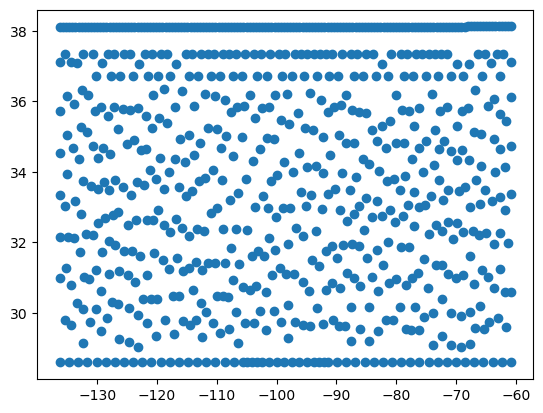

triangulate 2d:


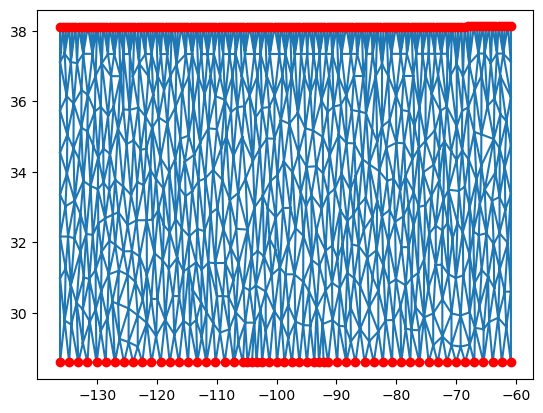

project back to 3d:


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(34.924993…

In [9]:
import numpy as np
import trimesh
import igl
from collections import defaultdict
from typing import List, Tuple
from primitive_fitting import *
from hole_filling import triangulate_refine_fair
import meshplot as mp
import matplotlib.pyplot as plt
from triangulate_2d import *


class CylinderHoleFilling:
    def __init__(self, 
        v, f, 
        c0, axis, r,
        max_area: float = 1.0,
        visualize: bool = False
    ):

        # v, f = igl.read_triangle_mesh(ply_in) 
        boundary_loops = igl.boundary_loop(f)
        boundary_v = v[boundary_loops]
        

        theta_bias = self.get_angle_bias(boundary_v, c0, axis, r)
        v_2d = self.project_points_to_cylinder_uv(boundary_v, c0, axis, r, theta_bias)
        adding_v_2d, raw_adding_f = triangulate_2d(v_2d, max_area=max_area)

        adding_v_3d = self.project_points_to_cylinder_xyz(adding_v_2d, c0, axis, r, theta_bias)
        
        self.new_v = np.vstack([v, adding_v_3d])
        self.new_f = np.vstack([f, raw_adding_f + self.new_v.shape[0] - adding_v_2d.shape[0]])
        self.adding_f_id = np.arange(f.shape[0], self.new_f.shape[0])

        if visualize:
            print(f'boundary len: {boundary_v.shape[0]}')
            plot = mp.plot(v, f, np.ones((f.shape[0], 3)), shading={
                'wireframe': True
            })
            plot.add_points(boundary_v, shading={
                'point_size': 3,
                'point_color': 'red'
            })

            print('project to 2d:')
            plt.figure()
            plt.scatter(adding_v_2d[:, 0], adding_v_2d[:, 1])
            plt.show()

            print('triangulate 2d:')
            plt.figure()
            plt.triplot(adding_v_2d[:, 0], adding_v_2d[:, 1], raw_adding_f)
            plt.scatter(v_2d[:, 0], v_2d[:, 1], color='red')
            plt.show()
            
            print('project back to 3d:')
            plot = mp.plot(self.new_v, self.new_f, np.ones((self.new_f.shape[0], 3)), shading={
                'wireframe': True
            })
            plot.add_points(adding_v_3d, shading={
                'point_size': 3,
                'point_color': 'red'
            })


    def get_angle_bias(self, boundary_v, c0, axis, r):
        e1, e2 = self.get_ortho_basis(axis)

        angles = []
        for v in boundary_v:
            theta, _ = self.get_cylinder_coords(v - c0, axis, e1, e2)
            angles.append(theta)
        angles = np.unwrap(np.array(angles))

        a0 = np.mod(angles - angles[0], 2 * np.pi)
        a_sorted = np.sort(a0)
        diffs = np.diff(a_sorted, prepend=a_sorted[-1] - 2 * np.pi)
        k = np.argmax(diffs)
        gap_start = a_sorted[k]
        gap_size = diffs[k]
        seam_rel = gap_start + gap_size / 2.0

        theta_bias = angles[0] + seam_rel
        theta_bias = (theta_bias + np.pi) % (2 * np.pi) - np.pi
        return theta_bias

        

    def get_ortho_basis(self, axis):
        tmp = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(tmp, axis)) > 0.9:
            tmp = np.array([0.0, 1.0, 0.0])
        e1 = np.cross(axis, tmp)
        e1 /= np.linalg.norm(e1)
        e2 = np.cross(axis, e1)
        return e1, e2
    
    def get_cylinder_coords(self, p, axis, e1, e2):
        h = np.dot(p, axis)

        x = np.dot(p, e1)
        y = np.dot(p, e2)
        theta = np.arctan2(y, x)
        return h, theta

    def project_points_to_cylinder_uv(self, pts, c0, axis, r, theta_bias):
        e1, e2 = self.get_ortho_basis(axis)

        pts_rel = pts - c0[None, :]
        h = np.empty(pts.shape[0], dtype=np.float64)
        theta = np.empty(pts.shape[0], dtype=np.float64)
        for i in range(pts.shape[0]):
            h[i], theta[i] = self.get_cylinder_coords(pts_rel[i], axis, e1, e2)
        theta = np.unwrap(theta) - theta_bias

        u = r * theta
        v = h
        UV = np.stack([u, v], axis=1)
        
        return UV

    def project_points_to_cylinder_xyz(self, UV, c0, axis, r, theta_bias):
        e1, e2 = self.get_ortho_basis(axis)

        u, v = UV[:, 0], UV[:, 1]
        theta = u / r + theta_bias
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)

        points = c0[None, :] + r * (cos_theta[:, None] * e1[None, :] + sin_theta[:, None] * e2[None, :]) + v[:, None] * axis[None, :]
        return points



        
    

if __name__ == "__main__":

    params = np.array([-1.74334303e-02, 4.12680082e+01, 7.30204089e+01, 9.99999973e-01, 1.89905324e-04, 1.31421002e-04, 1.90497009e+01])
    c0 = params[0:3]
    axis = params[3:6]
    r = params[6].item()

    ply_in = 'D:\Desktop\MeshSegment\example_results\merge\selected\\2\iter_2_part_1.ply'
    v, f = igl.read_triangle_mesh(ply_in)

    CylinderHoleFilling(
        v, f,
        c0=c0,
        axis=axis,
        r=r, visualize=True
    )